In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("/healthcare_dataset.csv")
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [8]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [9]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [10]:
billing = df.groupby(["Medical Condition","Insurance Provider"])["Billing Amount"].sum().unstack()
billing

Insurance Provider,Aetna,Blue Cross,Cigna,Medicare,UnitedHealthcare
Medical Condition,,,,,
Arthritis,4.667744e+07,4.776824e+07,4.810453e+07,4.677861e+07,4.800029e+07
Asthma,4.497371e+07,4.613516e+07,4.883917e+07,4.722901e+07,4.828272e+07
Cancer,4.533568e+07,4.538242e+07,4.768493e+07,4.728065e+07,4.648417e+07
Diabetes,4.709108e+07,4.802529e+07,4.855774e+07,4.885277e+07,4.601285e+07
Hypertension,4.858130e+07,4.658659e+07,4.527089e+07,4.767472e+07,4.760715e+07
Obesity,4.620389e+07,4.935658e+07,4.868209e+07,4.790500e+07,4.606736e+07


<Axes: xlabel='Medical Condition'>

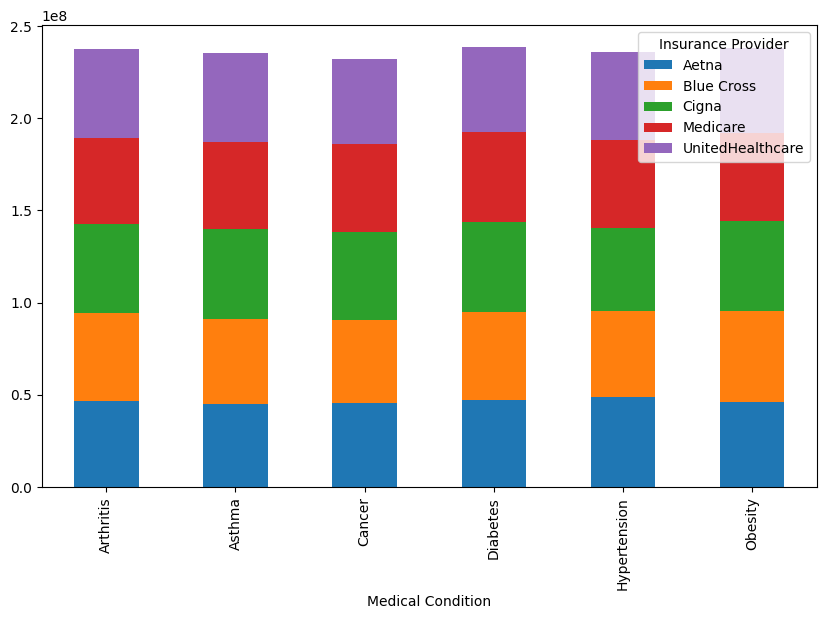

In [11]:
billing.plot(
    kind = "bar",
    stacked = True,
    figsize = (10,6)
)

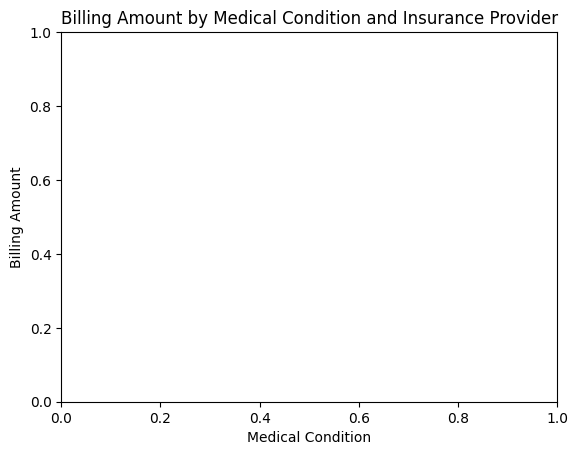

In [12]:
plt.title("Billing Amount by Medical Condition and Insurance Provider")
plt.xlabel("Medical Condition")
plt.ylabel("Billing Amount")
plt.show()

In [13]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Hospital_Stay_Days'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
print(df['Billing Amount'].describe())
print(df['Hospital_Stay_Days'].describe())

count    55500.000000
mean     25539.316097
std      14211.454431
min      -2008.492140
25%      13241.224652
50%      25538.069376
75%      37820.508436
max      52764.276736
Name: Billing Amount, dtype: float64
count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Hospital_Stay_Days, dtype: float64


In [16]:
df['Admission Month']=df['Date of Admission'].dt.to_period('M')
df['Admission Month']

,Admission Month
0,2024-01
1,2019-08
2,2022-09
3,2020-11
4,2022-09
...,...
55495,2020-08
55496,2020-01
55497,2020-07
55498,2019-05


In [28]:
monthly_admission = df.groupby('Admission Month').size()
monthly_admission

,0
Admission Month,
2019-05,686
2019-06,907
2019-07,957
2019-08,1001
2019-09,936
...,...
2024-01,909
2024-02,880
2024-03,906


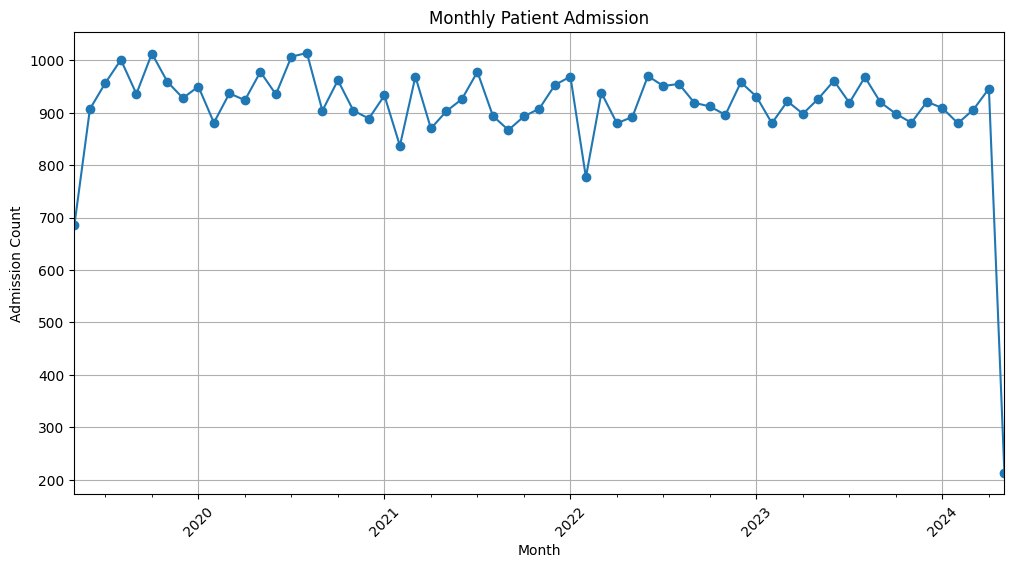

In [34]:
plt.figure(figsize=(12, 6))
monthly_admission.plot(kind="line", marker="o")

plt.title("Monthly Patient Admission")
plt.xlabel("Month")
plt.ylabel("Admission Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [35]:
correlation_matrix = df['Date of Admission']
df['Date of Admission']

,Date of Admission
0,2024-01-31
1,2019-08-20
2,2022-09-22
3,2020-11-18
4,2022-09-19
...,...
55495,2020-08-16
55496,2020-01-23
55497,2020-07-13
55498,2019-05-25


In [36]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

df['Stay Duration'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

correlation_matrix = df[['Age', 'Stay Duration', 'Billing Amount']].corr()
correlation_matrix

,Age,Stay Duration,Billing Amount
Age,1.000000,0.008220,-0.003832
Stay Duration,0.008220,1.000000,-0.005602
Billing Amount,-0.003832,-0.005602,1.000000


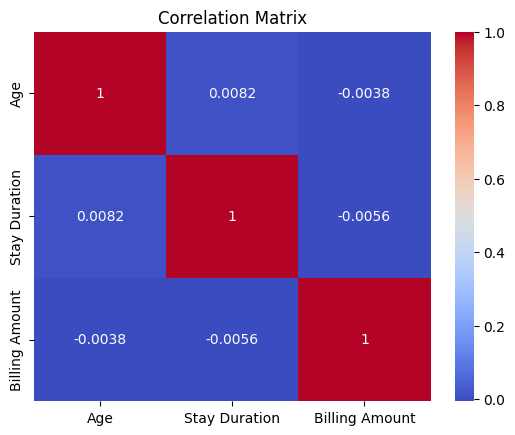

In [37]:
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()